In [115]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

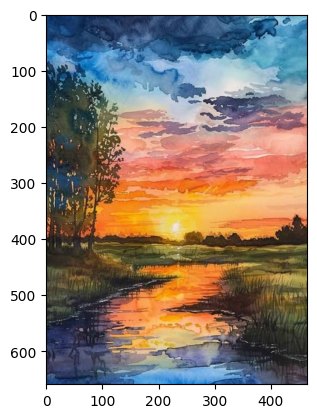

In [116]:
paint = cv2.imread("paint.jpg")
paint = cv2.cvtColor(paint, cv2.COLOR_BGR2RGB)
plt.imshow(paint)



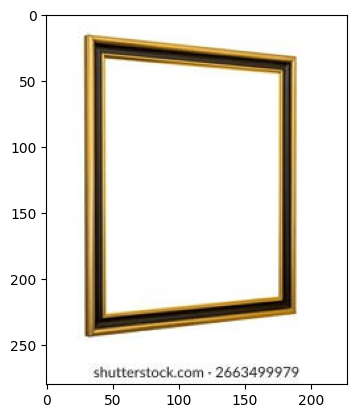

In [117]:
frame = cv2.imread("frame.jpg")
frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB )
plt.imshow(frame)

In [118]:
#scale first
scale = 20
small_paint = cv2.resize(paint,None,fx=scale,fy=scale)


In [119]:
#Rigid
h,w = small_paint.shape[:2]
cx = w/2
cy = h/2

angle = 40
R = cv2.getRotationMatrix2D((cx,cy), angle , 1)

R[0,2] += 20
R[1,2] += 30

rigid_paint = cv2.warpAffine(small_paint, R, (w,h))

In [120]:
h,w = rigid_paint.shape[:2]
src = np.float32([[0,0], [w,0],[w,h],[0,h]])

In [121]:
dst = np.float32([[62,15], [10,25], [40,240],[10,230]])

In [122]:
H = cv2.getPerspectiveTransform(src,dst)

In [123]:
fh,fw = frame.shape[:2]
result = cv2.warpPerspective(rigid_paint,H,(fw,fh))

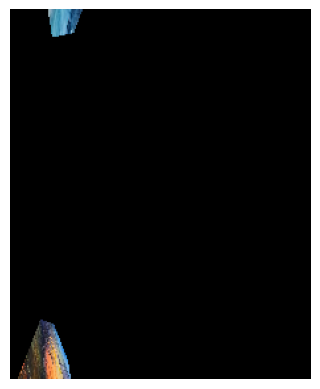

In [124]:
plt.imshow(result)
plt.axis("off")
plt.show()